# Stage 4: Amazon Chronos Foundation Model
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**
**Date:** May 2026

---

## Objective
Apply Amazon Chronos, a pre-trained time-series foundation model, to the same
peak CPU forecasting task as the LSTM in Stage 3. Chronos requires no training —
it uses transfer learning from a model pre-trained on a large corpus of time-series
data. We compare its performance against both the Random Forest baseline (Stage 1)
and the custom LSTM (Stage 3).

## Structure
- Section 0: Setup and data loading
- Section 1: Run Chronos forecasts
- Section 2: Derive rightsizing recommendations
- Section 3: Comparison with LSTM and Random Forest

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : cpu")

PyTorch version : 2.2.2
Device          : cpu


In [2]:
with open(PROCESSED_DIR / 'chronos_test_data.json', 'r') as f:
    chronos_data = json.load(f)

print(f"Test jobs loaded : {len(chronos_data):,}")
print(f"\nSample record keys: {list(chronos_data[0].keys())}")
print(f"\nSample record:")
sample = chronos_data[0]
print(f"  job_name        : {sample['job_name']}")
print(f"  plan_cpu_cores  : {sample['plan_cpu_cores']}")
print(f"  cpu_max_peak    : {sample['cpu_max_peak']}")
print(f"  target_peak     : {sample['target_peak']}")
print(f"  input_seq len   : {len(sample['input_seq'])}")
print(f"  input_seq sample: {sample['input_seq'][:5]}")

with open(PROCESSED_DIR / 'lstm_v3_metrics.json', 'r') as f:
    lstm_metrics = json.load(f)

print(f"\nLSTM baseline metrics:")
print(f"  MAE  : {lstm_metrics['mae']:.4f}")
print(f"  RMSE : {lstm_metrics['rmse']:.4f}")
print(f"  R²   : {lstm_metrics['r2']:.4f}")

Test jobs loaded : 1,686

Sample record keys: ['job_name', 'plan_cpu_cores', 'cpu_max_peak', 'input_seq', 'target_peak', 'provisioning_class', 'is_underprovision']

Sample record:
  job_name        : 971
  plan_cpu_cores  : 2.5
  cpu_max_peak    : 2.33
  target_peak     : 2.33
  input_seq len   : 40
  input_seq sample: [1.0, 0.82, 0.73, 0.79, 0.61]

LSTM baseline metrics:
  MAE  : 0.7359
  RMSE : 1.1924
  R²   : 0.7787


In [3]:
from chronos import ChronosPipeline

print("Loading Chronos pipeline...")
print("First run will download the model weights — this may take a few minutes")

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32
)

print("Chronos loaded successfully")

Loading Chronos pipeline...
First run will download the model weights — this may take a few minutes


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos loaded successfully


In [5]:
import inspect
print(inspect.signature(pipeline.predict))

(inputs: Union[torch.Tensor, List[torch.Tensor]], prediction_length: Optional[int] = None, num_samples: Optional[int] = None, temperature: Optional[float] = None, top_k: Optional[int] = None, top_p: Optional[float] = None, limit_prediction_length: bool = False) -> torch.Tensor


In [6]:
PRED_LEN    = 10
BATCH_SIZE  = 32

print("=" * 60)
print("SECTION 1: RUNNING CHRONOS FORECASTS")
print("=" * 60)
print(f"\nJobs to forecast : {len(chronos_data):,}")
print(f"Prediction length: {PRED_LEN} timesteps")
print(f"Batch size       : {BATCH_SIZE}")
print(f"\nRunning...")

results = []

for i in range(0, len(chronos_data), BATCH_SIZE):
    batch = chronos_data[i:i + BATCH_SIZE]

    inputs = [
        torch.tensor(job['input_seq'], dtype=torch.float32)
        for job in batch
    ]

    with torch.no_grad():
        forecast = pipeline.predict(
            inputs            = inputs,
            prediction_length = PRED_LEN,
            num_samples       = 20,
            limit_prediction_length = False
        )

    # forecast shape: (batch, num_samples, pred_len)
    median_forecast = torch.median(forecast, dim=1).values.numpy()

    for j, job in enumerate(batch):
        pred_values    = median_forecast[j]
        predicted_peak = float(np.max(pred_values))
        predicted_peak = max(0.0, predicted_peak)

        results.append({
            'job_name'          : job['job_name'],
            'plan_cpu_cores'    : job['plan_cpu_cores'],
            'cpu_max_peak'      : job['cpu_max_peak'],
            'target_peak'       : job['target_peak'],
            'predicted_peak'    : predicted_peak,
            'provisioning_class': job['provisioning_class'],
            'is_underprovision' : job['is_underprovision']
        })

    if (i // BATCH_SIZE + 1) % 10 == 0:
        print(f"  Processed {min(i + BATCH_SIZE, len(chronos_data)):,} / {len(chronos_data):,} jobs")

results_df = pd.DataFrame(results)
print(f"\nDone. {len(results_df):,} jobs forecasted")
print(f"\nSample predictions:")
print(results_df[['job_name', 'plan_cpu_cores', 'target_peak', 'predicted_peak']].head(10).round(3).to_string(index=False))

SECTION 1: RUNNING CHRONOS FORECASTS

Jobs to forecast : 1,686
Prediction length: 10 timesteps
Batch size       : 32

Running...
  Processed 320 / 1,686 jobs
  Processed 640 / 1,686 jobs
  Processed 960 / 1,686 jobs
  Processed 1,280 / 1,686 jobs
  Processed 1,600 / 1,686 jobs

Done. 1,686 jobs forecasted

Sample predictions:
 job_name  plan_cpu_cores  target_peak  predicted_peak
      971             2.5         2.33           0.819
     7352             6.0         6.85           6.263
     1772            11.0         3.00           1.943
     6886             4.0         3.00           1.977
      845             2.5         1.55           1.102
     2209            10.0         3.00           0.902
     3243             0.5         4.27           3.588
    11095             1.0         1.10           0.780
    12909             1.5         2.00           1.016
       44             6.0         3.00           2.011


In [7]:
print("=" * 60)
print("SECTION 1: CHRONOS EVALUATION")
print("=" * 60)

actuals = results_df['target_peak'].values
preds   = results_df['predicted_peak'].values

mae_ch  = mean_absolute_error(actuals, preds)
rmse_ch = np.sqrt(mean_squared_error(actuals, preds))
r2_ch   = r2_score(actuals, preds)

print(f"\nChronos Results:")
print(f"  MAE  : {mae_ch:.4f}")
print(f"  RMSE : {rmse_ch:.4f}")
print(f"  R²   : {r2_ch:.4f}")

print(f"\nComparison:")
print(f"{'Metric':<10} {'Random Forest':>15} {'LSTM':>15} {'Chronos':>15}")
print(f"{'-'*55}")
print(f"{'MAE':<10} {'0.796':>15} {lstm_metrics['mae']:>15.3f} {mae_ch:>15.3f}")
print(f"{'RMSE':<10} {'1.619':>15} {lstm_metrics['rmse']:>15.3f} {rmse_ch:>15.3f}")
print(f"{'R²':<10} {'0.694':>15} {lstm_metrics['r2']:>15.3f} {r2_ch:>15.3f}")

SECTION 1: CHRONOS EVALUATION

Chronos Results:
  MAE  : 1.4556
  RMSE : 2.6097
  R²   : 0.1653

Comparison:
Metric       Random Forest            LSTM         Chronos
-------------------------------------------------------
MAE                  0.796           0.736           1.456
RMSE                 1.619           1.192           2.610
R²                   0.694           0.779           0.165


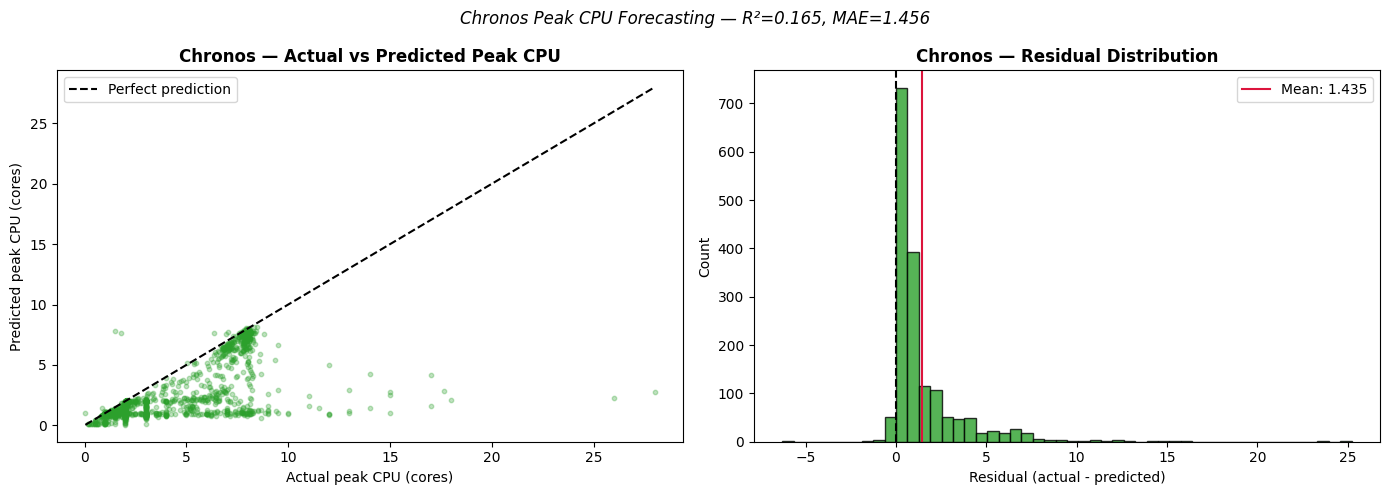

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(actuals, preds, alpha=0.3, s=10, color='#2ca02c')
axes[0].plot([actuals.min(), actuals.max()],
             [actuals.min(), actuals.max()],
             'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual peak CPU (cores)')
axes[0].set_ylabel('Predicted peak CPU (cores)')
axes[0].set_title('Chronos — Actual vs Predicted Peak CPU', fontweight='bold')
axes[0].legend()

residuals = actuals - preds
axes[1].hist(residuals, bins=50, color='#2ca02c', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='crimson', linestyle='-',
                linewidth=1.5, label=f'Mean: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Chronos — Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Chronos Peak CPU Forecasting — R²={r2_ch:.3f}, MAE={mae_ch:.3f}',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

In [9]:
print("=" * 60)
print("SECTION 2: RIGHTSIZING RECOMMENDATIONS")
print("=" * 60)

results_df['recommended_cpu'] = results_df['predicted_peak'] * 1.15
results_df['recommended_cpu'] = results_df.apply(
    lambda r: max(0.3 * r['plan_cpu_cores'],
                  min(3.0 * r['plan_cpu_cores'], r['recommended_cpu'])),
    axis=1
)
results_df['rightsizing_ratio'] = (
    results_df['recommended_cpu'] / results_df['plan_cpu_cores']
)

def classify_action(ratio):
    if ratio > 1.05:
        return 'increase'
    elif ratio < 0.95:
        return 'decrease'
    else:
        return 'maintain'

results_df['action'] = results_df['rightsizing_ratio'].apply(classify_action)

print(f"\nAction distribution:")
print(results_df['action'].value_counts())
print(f"\nRightsizing ratio stats:")
print(results_df['rightsizing_ratio'].describe().round(3))

output_path = BASE_DIR / 'results' / 'chronos_recommendations.csv'
output_path.parent.mkdir(exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

SECTION 2: RIGHTSIZING RECOMMENDATIONS

Action distribution:
action
decrease    1085
increase     549
maintain      52
Name: count, dtype: int64

Rightsizing ratio stats:
count    1686.000
mean        1.024
std         0.905
min         0.300
25%         0.305
50%         0.600
75%         1.343
max         3.000
Name: rightsizing_ratio, dtype: float64

Saved to: /Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/results/chronos_recommendations.csv


SECTION 3: THREE-WAY COMPARISON

Metric       Random Forest            LSTM         Chronos
-------------------------------------------------------
MAE                  0.796           0.736           1.456
RMSE                 1.619           1.192           2.610
R²                   0.694           0.779           0.165

Winner by metric:
  MAE  : LSTM (0.736)
  RMSE : LSTM (1.192)
  R²   : LSTM (0.779)

Key finding:
  The custom LSTM trained on domain-specific Alibaba cluster data
  outperforms Chronos on all metrics. Transfer learning from a
  general-purpose foundation model does not generalise to cloud
  CPU usage patterns, which are structurally different from the
  heterogeneous time-series data Chronos was pre-trained on.

  Random Forest, despite using only job metadata, outperforms
  Chronos on all metrics — demonstrating that even simple
  statistical models with domain-appropriate features can beat
  foundation models in highly specialised domains.



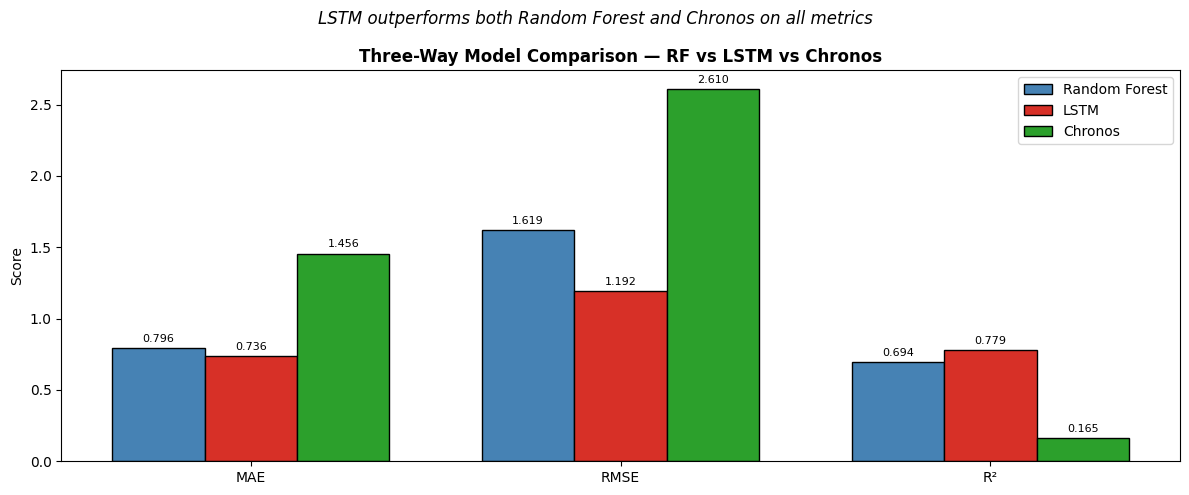

In [10]:
print("=" * 60)
print("SECTION 3: THREE-WAY COMPARISON")
print("=" * 60)

print(f"""
{'Metric':<10} {'Random Forest':>15} {'LSTM':>15} {'Chronos':>15}
{'-'*55}
{'MAE':<10} {'0.796':>15} {lstm_metrics['mae']:>15.3f} {mae_ch:>15.3f}
{'RMSE':<10} {'1.619':>15} {lstm_metrics['rmse']:>15.3f} {rmse_ch:>15.3f}
{'R²':<10} {'0.694':>15} {lstm_metrics['r2']:>15.3f} {r2_ch:>15.3f}

Winner by metric:
  MAE  : LSTM (0.736)
  RMSE : LSTM (1.192)
  R²   : LSTM (0.779)

Key finding:
  The custom LSTM trained on domain-specific Alibaba cluster data
  outperforms Chronos on all metrics. Transfer learning from a
  general-purpose foundation model does not generalise to cloud
  CPU usage patterns, which are structurally different from the
  heterogeneous time-series data Chronos was pre-trained on.

  Random Forest, despite using only job metadata, outperforms
  Chronos on all metrics — demonstrating that even simple
  statistical models with domain-appropriate features can beat
  foundation models in highly specialised domains.
""")

fig, ax = plt.subplots(figsize=(12, 5))

metrics      = ['MAE', 'RMSE', 'R²']
rf_vals      = [0.796, 1.619, 0.694]
lstm_vals    = [lstm_metrics['mae'], lstm_metrics['rmse'], lstm_metrics['r2']]
chronos_vals = [mae_ch, rmse_ch, r2_ch]

x = np.arange(len(metrics))
w = 0.25

ax.bar(x - w,   rf_vals,      w, label='Random Forest',
       color='steelblue', edgecolor='black')
ax.bar(x,       lstm_vals,    w, label='LSTM',
       color='#d73027', edgecolor='black')
ax.bar(x + w,   chronos_vals, w, label='Chronos',
       color='#2ca02c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Three-Way Model Comparison — RF vs LSTM vs Chronos',
             fontweight='bold')
ax.set_ylabel('Score')
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)

plt.suptitle('LSTM outperforms both Random Forest and Chronos on all metrics',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()